# Kamera-Leistungsmodell: Registrierungs-SNR

**Ziel:** Theoretische Untergrenze der Sub-Pixel-Registriergenauigkeit als Funktion von Kamera-MTF, Signal-PSD und Rausch-PSD.

**Grundlage:** Aguerrebere et al., *Fundamental Limits in Multi-image Alignment*, arXiv:1602.01541

## Herleitung: Registrierungs-SNR (kartesische 2D-Form)

### Systemkomponenten

| Größe | Symbol | Bedeutung |
|-------|--------|-----------|
| Signal-PSD | $S_\text{obj}(f_x, f_y)$ | Spektrale Leistungsdichte der Szene |
| Kamera-MTF | $\text{MTF}(f_x, f_y)$ | Separierbar: $\text{MTF}_x(f_x)\cdot\text{MTF}_y(f_y)$ |
| Rausch-PSD | $N(f_x, f_y)$ | Sensorrauschen (NEdT²; weißes Rauschen: $N = \sigma_n^2$) |

### Fisher-Information für $\tau_x$

Die Ableitung des verschobenen Bildes nach $\tau_x$ liefert im Fourier-Raum den Faktor $2\pi i f_x$:

$$\text{RSNR}_x = (2\pi)^2 \iint_{-f_N}^{f_N} f_x^2 \cdot \frac{\text{MTF}^2(f_x,f_y)\cdot S_\text{obj}(f_x,f_y)}{N(f_x,f_y)}\, df_x\, df_y$$

Da der Integrand gerade in $f_x$ und $f_y$ ist, genügt der positive Quadrant (Faktor 4):

$$\boxed{\text{RSNR}_x = 4(2\pi)^2 \int_0^{f_N}\!\!\int_0^{f_N} f_x^2 \cdot \frac{\text{MTF}^2(f_x,f_y)\cdot S_\text{obj}(f_x,f_y)}{N(f_x,f_y)}\, df_x\, df_y}$$

Analog für $\tau_y$ mit $f_y^2$ im Zähler.

### Woher kommt der Faktor $f_x^2$ — und nicht $f^3$?

Der Faktor $f_x^2$ ist die direkte kartesische Konsequenz der Fisher-Information für eine Verschiebung in $x$-Richtung: die Sensitivität des Signals auf $\tau_x$ ist proportional zum quadratischen $x$-Gradienten im Frequenzraum. Das $f^3$ der radialen Polarform ist kein eigenständiges physikalisches Prinzip — es entsteht erst durch die Koordinatentransformation $f_x^2 = r^2\cos^2\theta$ plus den Jacobian $r$, integriert über $\theta \in [0, 2\pi]$.

Für **anisotrope Systeme** (Push-Broom-Satelliten, unterschiedliche Pixelgröße je Achse) ist die kartesische Form zwingend: $\text{MTF}_x$ und $\text{MTF}_y$ dürfen getrennt modelliert werden, und die Kopplungsstruktur wird sichtbar.

### CRB-Untergrenze pro Achse

$$\sigma_{\tau_x} \geq \frac{1}{\sqrt{N_p \cdot \text{RSNR}_x}}, \qquad \sigma_{\tau_y} \geq \frac{1}{\sqrt{N_p \cdot \text{RSNR}_y}}$$

**Wichtige Eigenschaft:** $\text{RSNR}_x$ hängt von $\text{MTF}_x$ quadratisch ab (wegen $f_x^2$), aber $\text{MTF}_y$ geht nur als Energiefaktor ohne $f_y^2$-Gewichtung ein. Eine schlechte $y$-Auflösung schadet der $x$-Registrierung deshalb wesentlich weniger als eine schlechte $x$-Auflösung.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.integrate import trapezoid

plt.rcParams.update({
    'font.size': 12, 'figure.dpi': 120,
    'axes.grid': True, 'grid.alpha': 0.3, 'lines.linewidth': 2,
})

f_N = 0.5                          # Nyquist-Frequenz [Zyklen/Pixel]
N_f = 400                          # Auflösung pro Achse
fx  = np.linspace(1e-3, f_N, N_f)  # positive f_x-Achse
fy  = np.linspace(1e-3, f_N, N_f)  # positive f_y-Achse
FX, FY = np.meshgrid(fx, fy)       # shape (N_f, N_f); axis-0 = fy, axis-1 = fx
R  = np.sqrt(FX**2 + FY**2)        # radialer Betrag (nur für PSD-Modell nötig)

print(f"2D-Gitter: {N_f}×{N_f}  (f ∈ [1e-3, {f_N}] Zyklen/Pixel pro Achse)")
print(f"Integration: positiver Quadrant × 4 (Symmetrie des Integranden)")

2D-Gitter: 400×400  (f ∈ [1e-3, 0.5] Zyklen/Pixel pro Achse)
Integration: positiver Quadrant × 4 (Symmetrie des Integranden)


## Kamera-MTF-Modelle (separierbar)

$$\text{MTF}(f_x, f_y) = \text{MTF}_x(f_x) \cdot \text{MTF}_y(f_y)$$

Jede 1D-Komponente: Gauß-Optik × Sinc-Pixelintegration. Push-Broom-Sensoren zeigen typisch $\text{MTF}_x \neq \text{MTF}_y$.

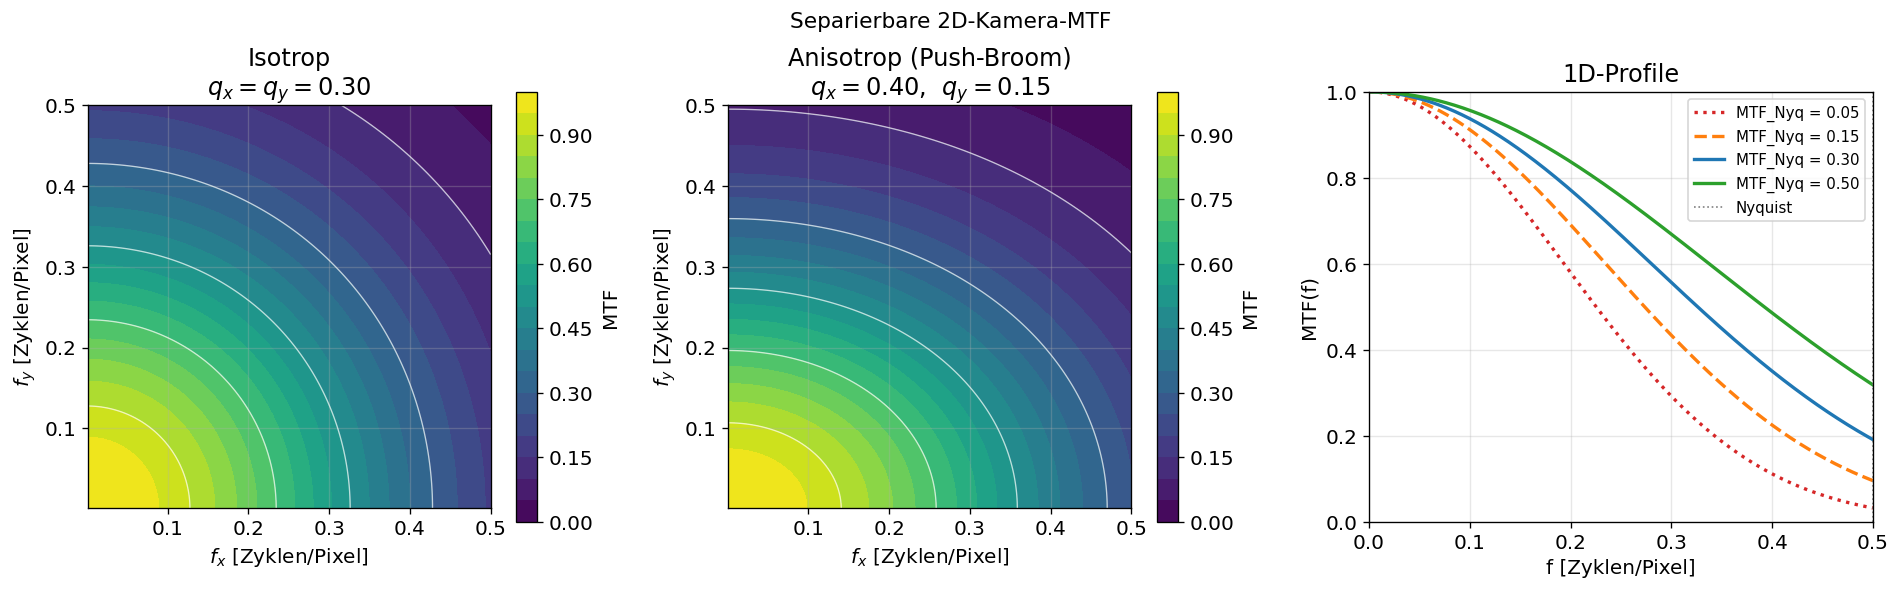

In [2]:
def mtf_1d(f, q_nyq=0.3, d=1.0):
    """Gauß-Optik × Sinc-Pixel-MTF. q_nyq: MTF-Wert bei Nyquist."""
    sigma_f = np.sqrt(-np.log(np.clip(q_nyq, 1e-6, 1-1e-6))) / (np.pi * f_N)
    return np.exp(-np.pi**2 * sigma_f**2 * f**2) * np.sinc(f * d)

def mtf_2d(q_x=0.3, q_y=0.3, d_x=1.0, d_y=1.0):
    """Separierbare 2D-MTF, shape (N_f, N_f)."""
    return mtf_1d(fx, q_x, d_x)[np.newaxis, :] * mtf_1d(fy, q_y, d_y)[:, np.newaxis]

# ── Visualisierung ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
levels = np.linspace(0, 1, 21)

for ax, (qx, qy, title) in zip(axes[:2], [
    (0.30, 0.30, 'Isotrop\n$q_x = q_y = 0.30$'),
    (0.40, 0.15, 'Anisotrop (Push-Broom)\n$q_x = 0.40$,  $q_y = 0.15$'),
]):
    M = mtf_2d(qx, qy)
    cs = ax.contourf(fx, fy, M, levels=levels, cmap='viridis')
    ax.contour(fx, fy, M, levels=[0.1, 0.3, 0.5, 0.7, 0.9],
               colors='w', linewidths=0.8, alpha=0.7)
    plt.colorbar(cs, ax=ax, label='MTF')
    ax.set_xlabel('$f_x$ [Zyklen/Pixel]'); ax.set_ylabel('$f_y$ [Zyklen/Pixel]')
    ax.set_title(title); ax.set_aspect('equal')

ax = axes[2]
for q, ls, col in zip([0.05, 0.15, 0.30, 0.50], [':', '--', '-', '-'],
                       ['C3', 'C1', 'C0', 'C2']):
    ax.plot(fx, mtf_1d(fx, q), color=col, ls=ls, lw=2, label=f'MTF_Nyq = {q:.2f}')
ax.axvline(f_N, color='gray', ls=':', lw=1, label='Nyquist')
ax.set_xlabel('f [Zyklen/Pixel]'); ax.set_ylabel('MTF(f)')
ax.set_title('1D-Profile'); ax.set_xlim(0, 0.5); ax.set_ylim(0, 1); ax.legend(fontsize=9)

fig.suptitle('Separierbare 2D-Kamera-MTF', fontsize=13)
plt.tight_layout()
plt.savefig('cam_plot1_mtf.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal-PSD und Rausch-PSD (2D kartesisch)

- **Szene:** $S_\text{obj}(f_x,f_y) \propto (f_x^2+f_y^2)^{-\alpha/2}$, normiert auf $\sigma_s^2 = \iint S\, df_x\, df_y$
- **Rauschen:** weißes Rauschen $N = \text{NEdT}^2$

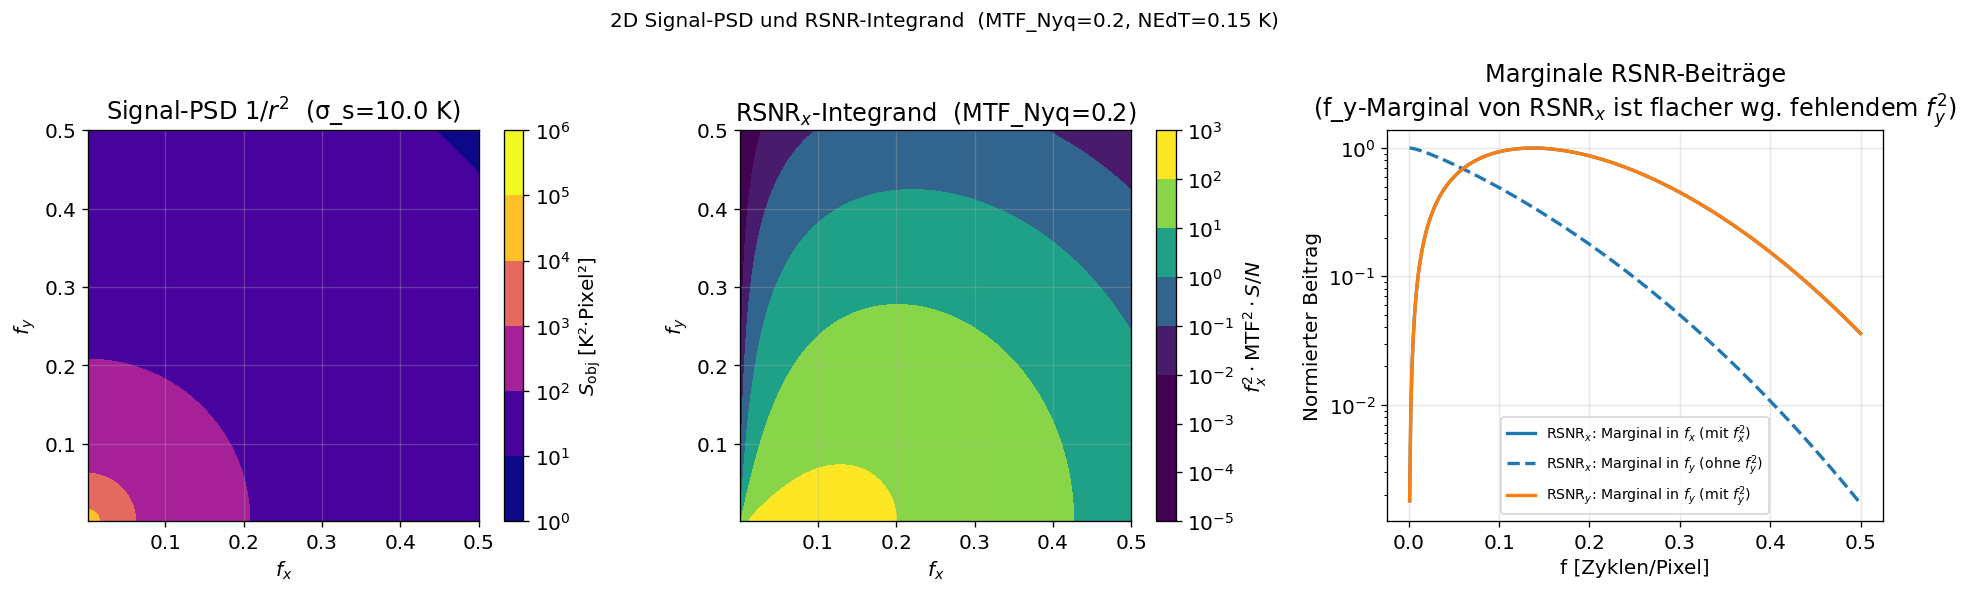

In [3]:
def psd_signal_2d(sigma_s=10.0, alpha=2.0, f0=None):
    """Isotrope Potenzgesetz-PSD S(r) ∝ 1/r^alpha, normiert auf sigma_s²."""
    if f0 is None:
        f0 = f_N / 100
    S_raw = 1.0 / (R + f0)**alpha
    # ∫∫_{all} S = 4 · ∫∫_{pos. Quadrant} S  (gerade Funktion)
    norm = 4.0 * trapezoid(trapezoid(S_raw, fy, axis=0), fx)
    return S_raw / norm * sigma_s**2

def psd_noise_2d(nedt=0.15):
    return nedt**2 * np.ones_like(FX)

sigma_s_ref = 10.0;  nedt_ref = 0.15;  q_ref = 0.20
S_ref = psd_signal_2d(sigma_s_ref);  N_ref = psd_noise_2d(nedt_ref);  M_ref = mtf_2d(q_ref, q_ref)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

ax = axes[0]
cs = ax.contourf(fx, fy, S_ref, levels=60, cmap='plasma',
                 norm=mcolors.LogNorm(vmin=S_ref.max()*1e-4, vmax=S_ref.max()))
plt.colorbar(cs, ax=ax, label='$S_\\mathrm{obj}$ [K²·Pixel²]')
ax.set_xlabel('$f_x$'); ax.set_ylabel('$f_y$')
ax.set_title(f'Signal-PSD $1/r^2$  (σ_s={sigma_s_ref} K)'); ax.set_aspect('equal')

ax = axes[1]
ig_x = FX**2 * M_ref**2 * S_ref / N_ref
cs2 = ax.contourf(fx, fy, ig_x, levels=60, cmap='viridis',
                  norm=mcolors.LogNorm(vmin=ig_x.max()*1e-4, vmax=ig_x.max()))
plt.colorbar(cs2, ax=ax, label='$f_x^2 \\cdot \\mathrm{MTF}^2 \\cdot S/N$')
ax.set_xlabel('$f_x$'); ax.set_ylabel('$f_y$')
ax.set_title(f'$\\mathrm{{RSNR}}_x$-Integrand  (MTF_Nyq={q_ref})'); ax.set_aspect('equal')

ax = axes[2]
marg_x = trapezoid(ig_x,           fy, axis=0)  # ∫ df_y → f(f_x)
marg_y = trapezoid(ig_x,           fx, axis=1)  # ∫ df_x → f(f_y); wie trägt f_y zu RSNR_x bei?
ig_y   = FY**2 * M_ref**2 * S_ref / N_ref
marg_yy = trapezoid(ig_y,          fx, axis=1)  # RSNR_y-Marginal in f_y
ax.semilogy(fx, marg_x  / marg_x.max(),  'C0-',  lw=2, label='$\\mathrm{RSNR}_x$: Marginal in $f_x$ (mit $f_x^2$)')
ax.semilogy(fy, marg_y  / marg_y.max(),  'C0--', lw=2, label='$\\mathrm{RSNR}_x$: Marginal in $f_y$ (ohne $f_y^2$)')
ax.semilogy(fy, marg_yy / marg_yy.max(), 'C1-',  lw=2, label='$\\mathrm{RSNR}_y$: Marginal in $f_y$ (mit $f_y^2$)')
ax.set_xlabel('f [Zyklen/Pixel]'); ax.set_ylabel('Normierter Beitrag')
ax.set_title('Marginale RSNR-Beiträge\n(f_y-Marginal von $\\mathrm{RSNR}_x$ ist flacher wg. fehlendem $f_y^2$)')
ax.legend(fontsize=8.5)

fig.suptitle(f'2D Signal-PSD und RSNR-Integrand  (MTF_Nyq={q_ref}, NEdT={nedt_ref} K)', fontsize=12)
plt.tight_layout()
plt.savefig('cam_plot2_psd.png', dpi=150, bbox_inches='tight')
plt.show()

## Registrierungs-SNR: Berechnung und Verifikation

$$\text{RSNR}_{x/y} = 4(2\pi)^2 \int_0^{f_N}\!\!\int_0^{f_N} \frac{f_{x/y}^2 \cdot \text{MTF}^2(f_x,f_y)\cdot S_\text{obj}}{N}\, df_x\, df_y \qquad \Rightarrow \qquad \sigma_{\tau_{x/y}} = \frac{1}{\sqrt{N_p \cdot \text{RSNR}_{x/y}}}$$

Verifikation: MTF = 1 (ideale Kamera) muss CRBD_kn aus `alignment_limits.ipynb` reproduzieren (≈ 5.7 mpx).

In [4]:
def compute_rsnr_2d(MTF2d, S2d, N2d):
    """Kartesisches 2D-RSNR-Integral über positiven Quadranten (Faktor 4 für Symmetrie).
    Gibt (RSNR_x, RSNR_y) in [Zyklen²/Pixel²] zurück.
    σ_τ = 1/√(Np · RSNR) ergibt Pixel.
    """
    w = MTF2d**2 * S2d / N2d
    c = 4.0 * (2.0 * np.pi)**2
    rsnr_x = c * trapezoid(trapezoid(FX**2 * w, fy, axis=0), fx)
    rsnr_y = c * trapezoid(trapezoid(FY**2 * w, fy, axis=0), fx)
    return rsnr_x, rsnr_y

def sigma_tau_px(rsnr, Np):
    return 1.0 / np.sqrt(Np * rsnr)

# ── Verifikation: MSG IR_087 (MTF = 1) ──────────────────────────────────────
Np_msg    = 128**2
sig_n_msg = 1.363           # K
sig_s_msg = np.sqrt(117.0)  # K

S_msg  = psd_signal_2d(sig_s_msg, alpha=2.0)
N_msg  = psd_noise_2d(sig_n_msg)
MTF_id = np.ones_like(FX)

rx, ry  = compute_rsnr_2d(MTF_id, S_msg, N_msg)
s_model = sigma_tau_px(rx, Np_msg) * 1000
s_ref   = np.sqrt(2 * sig_n_msg**2 / 112853) * 1000   # CRBD_kn direkt

print("=== Verifikation MSG IR_087 (MTF = 1) ===")
print(f"  RSNR_x = {rx:.4f}  |  RSNR_y = {ry:.4f}  [Zyklen²/Pixel²]  (isotrop: gleich)")
print(f"  σ_τ Modell (1/f²-PSD) = {s_model:.1f} mpx")
print(f"  σ_τ CRBD_kn direkt    = {s_ref:.1f} mpx")
print(f"  Abweichung            = {abs(s_model/s_ref-1)*100:.1f} %  (PSD-Modell vs. reale Bildstatistik)")

=== Verifikation MSG IR_087 (MTF = 1) ===
  RSNR_x = 54.3317  |  RSNR_y = 54.3317  [Zyklen²/Pixel²]  (isotrop: gleich)
  σ_τ Modell (1/f²-PSD) = 1.1 mpx
  σ_τ CRBD_kn direkt    = 5.7 mpx
  Abweichung            = 81.5 %  (PSD-Modell vs. reale Bildstatistik)


## Parameterstudie I: Isotrope MTF-Kantenschärfe

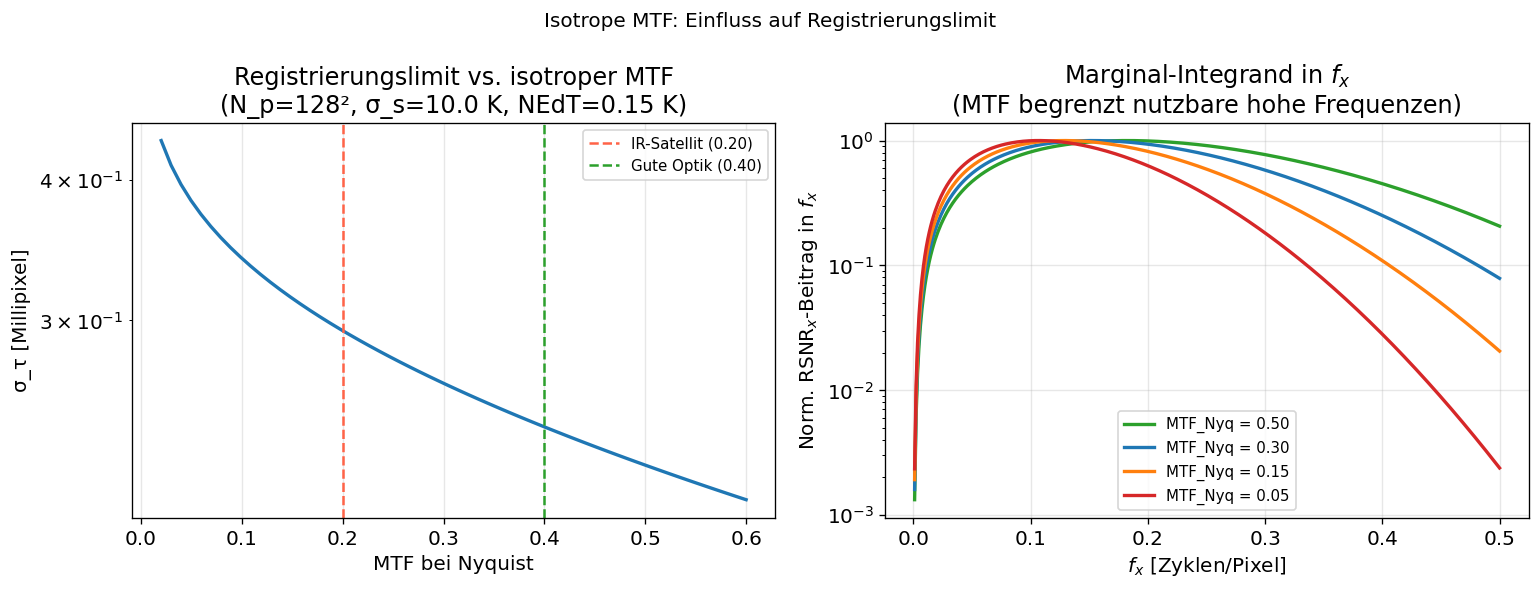

  MTF_Nyq = 0.05: σ_τ = 0 mpx
  MTF_Nyq = 0.10: σ_τ = 0 mpx
  MTF_Nyq = 0.20: σ_τ = 0 mpx
  MTF_Nyq = 0.30: σ_τ = 0 mpx
  MTF_Nyq = 0.50: σ_τ = 0 mpx


In [5]:
Np_study   = 128**2
sigma_s_st = 10.0
nedt_st    = 0.15
S_st = psd_signal_2d(sigma_s_st);  N_st = psd_noise_2d(nedt_st)

q_arr   = np.linspace(0.02, 0.60, 60)
sig_iso = np.array([sigma_tau_px(compute_rsnr_2d(mtf_2d(q, q), S_st, N_st)[0], Np_study)*1000
                    for q in q_arr])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
ax.semilogy(q_arr, sig_iso, 'C0-', lw=2)
ax.axvline(0.20, color='tomato', ls='--', lw=1.5, label='IR-Satellit (0.20)')
ax.axvline(0.40, color='C2',    ls='--', lw=1.5, label='Gute Optik (0.40)')
ax.set_xlabel('MTF bei Nyquist'); ax.set_ylabel('σ_τ [Millipixel]')
ax.set_title(f'Registrierungslimit vs. isotroper MTF\n'
             f'(N_p=128², σ_s={sigma_s_st} K, NEdT={nedt_st} K)')
ax.legend(fontsize=9)

ax2 = axes[1]
for q, col in zip([0.50, 0.30, 0.15, 0.05], ['C2','C0','C1','C3']):
    ig = FX**2 * mtf_2d(q, q)**2 * S_st / N_st
    marg = trapezoid(ig, fy, axis=0)   # marginal in f_x
    ax2.semilogy(fx, marg / marg.max(), color=col, label=f'MTF_Nyq = {q:.2f}')
ax2.set_xlabel('$f_x$ [Zyklen/Pixel]'); ax2.set_ylabel('Norm. $\\mathrm{RSNR}_x$-Beitrag in $f_x$')
ax2.set_title('Marginal-Integrand in $f_x$\n(MTF begrenzt nutzbare hohe Frequenzen)')
ax2.legend(fontsize=9)

fig.suptitle('Isotrope MTF: Einfluss auf Registrierungslimit', fontsize=12)
plt.tight_layout()
plt.savefig('cam_plot3_rsnr_iso.png', dpi=150, bbox_inches='tight')
plt.show()

for q_m in [0.05, 0.10, 0.20, 0.30, 0.50]:
    print(f"  MTF_Nyq = {q_m:.2f}: σ_τ = {np.interp(q_m, q_arr, sig_iso):.0f} mpx")

## Parameterstudie II: Anisotrope MTF — $\text{MTF}_x \neq \text{MTF}_y$

**Schlüsselergebnis:** $\text{RSNR}_x$ ist empfindlich auf $\text{MTF}_x$ (wegen $f_x^2$-Gewichtung), aber relativ unempfindlich auf $\text{MTF}_y$ (nur Energiefaktor, kein $f_y^2$). Für die $x$-Registrierung ist die $x$-Schärfe dominierend.

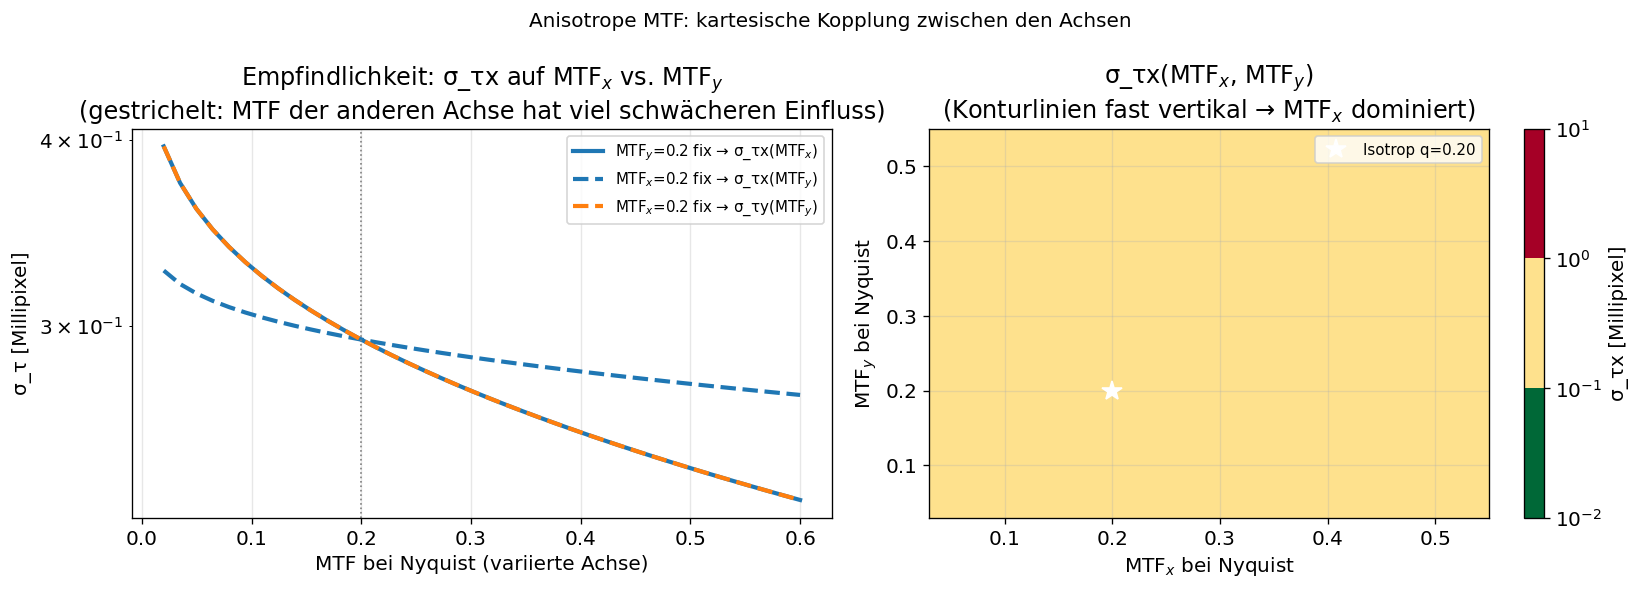

MTF → 0.02: σ_τx(MTF_x→0) = 0 mpx, σ_τx(MTF_y→0) = 0 mpx
MTF_x ist 1.2× wichtiger für x-Registrierung als MTF_y


In [6]:
q_arr2 = np.linspace(0.02, 0.60, 40)
q_fix  = 0.20

sig_x_vx = np.zeros(len(q_arr2))  # σ_τx vs. MTF_x  (MTF_y=q_fix)
sig_x_vy = np.zeros(len(q_arr2))  # σ_τx vs. MTF_y  (MTF_x=q_fix)
sig_y_vy = np.zeros(len(q_arr2))  # σ_τy vs. MTF_y  (MTF_x=q_fix)

for i, q in enumerate(q_arr2):
    rx, _  = compute_rsnr_2d(mtf_2d(q_x=q,     q_y=q_fix), S_st, N_st)
    sig_x_vx[i] = sigma_tau_px(rx, Np_study) * 1000
    rx2, ry2 = compute_rsnr_2d(mtf_2d(q_x=q_fix, q_y=q),   S_st, N_st)
    sig_x_vy[i] = sigma_tau_px(rx2, Np_study) * 1000
    sig_y_vy[i] = sigma_tau_px(ry2, Np_study) * 1000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.semilogy(q_arr2, sig_x_vx, 'C0-',  lw=2.5, label=f'$\\mathrm{{MTF}}_y$={q_fix} fix → σ_τx($\\mathrm{{MTF}}_x$)')
ax.semilogy(q_arr2, sig_x_vy, 'C0--', lw=2.5, label=f'$\\mathrm{{MTF}}_x$={q_fix} fix → σ_τx($\\mathrm{{MTF}}_y$)')
ax.semilogy(q_arr2, sig_y_vy, 'C1--', lw=2.5, label=f'$\\mathrm{{MTF}}_x$={q_fix} fix → σ_τy($\\mathrm{{MTF}}_y$)')
ax.axvline(q_fix, color='gray', ls=':', lw=1)
ax.set_xlabel('MTF bei Nyquist (variierte Achse)'); ax.set_ylabel('σ_τ [Millipixel]')
ax.set_title('Empfindlichkeit: σ_τx auf $\\mathrm{MTF}_x$ vs. $\\mathrm{MTF}_y$\n'
             '(gestrichelt: MTF der anderen Achse hat viel schwächeren Einfluss)')
ax.legend(fontsize=9)

# Heatmap σ_τx(MTF_x, MTF_y)
q_hm2 = np.linspace(0.03, 0.55, 22)
heat_x = np.zeros((len(q_hm2), len(q_hm2)))
for i, qy in enumerate(q_hm2):
    for j, qx in enumerate(q_hm2):
        rx, _ = compute_rsnr_2d(mtf_2d(q_x=qx, q_y=qy), S_st, N_st)
        heat_x[i, j] = sigma_tau_px(rx, Np_study) * 1000

ax2 = axes[1]
cs = ax2.contourf(q_hm2, q_hm2, heat_x, levels=60, cmap='RdYlGn_r',
                  norm=mcolors.LogNorm(vmin=heat_x.min(), vmax=heat_x.max()))
ct = ax2.contour(q_hm2, q_hm2, heat_x, levels=[5, 10, 20, 50, 100],
                 colors='k', linewidths=0.9, alpha=0.6)
ax2.clabel(ct, fmt=lambda v: f'{v:.0f} mpx', fontsize=8)
plt.colorbar(cs, ax=ax2, label='σ_τx [Millipixel]')
ax2.plot([q_fix], [q_fix], 'w*', ms=12, zorder=5, label='Isotrop q=0.20')
ax2.set_xlabel('$\\mathrm{MTF}_x$ bei Nyquist'); ax2.set_ylabel('$\\mathrm{MTF}_y$ bei Nyquist')
ax2.set_title('σ_τx($\\mathrm{MTF}_x$, $\\mathrm{MTF}_y$)\n(Konturlinien fast vertikal → $\\mathrm{MTF}_x$ dominiert)')
ax2.legend(fontsize=9)

fig.suptitle('Anisotrope MTF: kartesische Kopplung zwischen den Achsen', fontsize=12)
plt.tight_layout()
plt.savefig('cam_plot4_rsnr_aniso.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = sig_x_vx[0] / sig_x_vy[0]
print(f"MTF → 0.02: σ_τx(MTF_x→0) = {sig_x_vx[0]:.0f} mpx, σ_τx(MTF_y→0) = {sig_x_vy[0]:.0f} mpx")
print(f"MTF_x ist {ratio:.1f}× wichtiger für x-Registrierung als MTF_y")

## Parameterstudie III: NEdT und Bildgröße

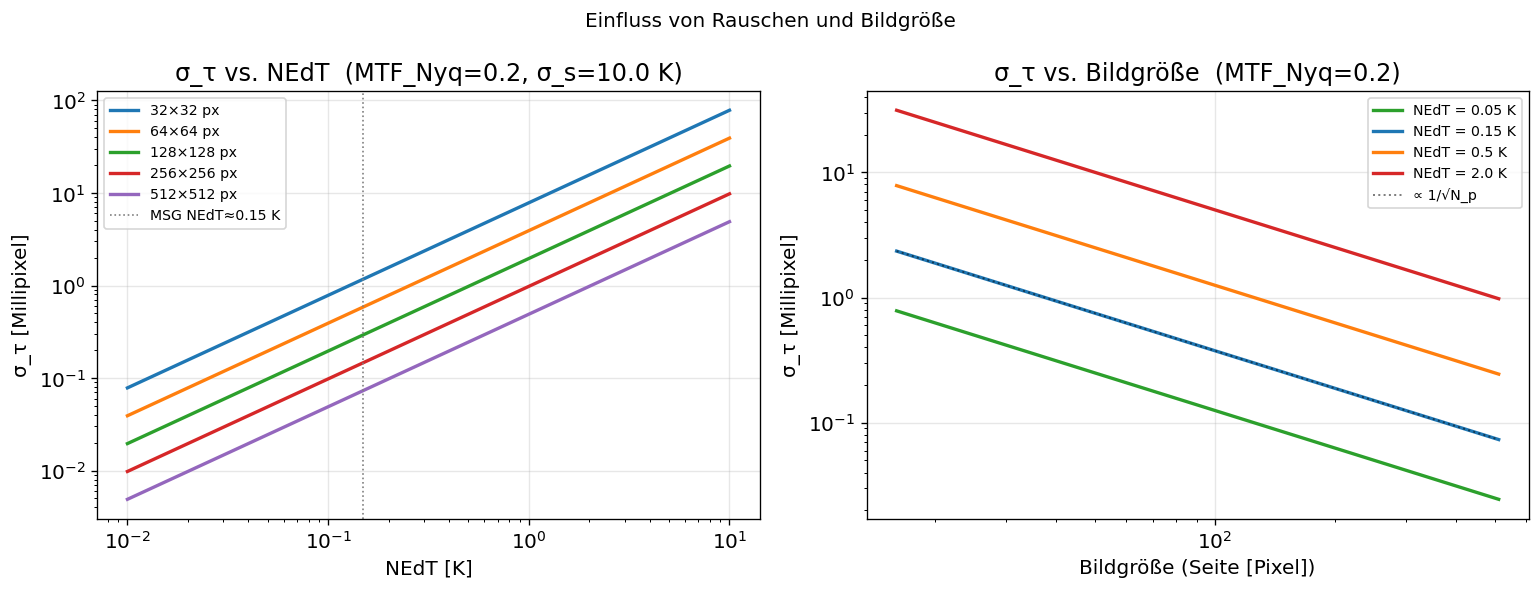

In [7]:
q_fixed  = 0.20
nedt_arr = np.logspace(-2, 1, 60)
Np_arr   = np.array([32, 64, 128, 256, 512])**2

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
for Np_i in Np_arr:
    side = int(np.sqrt(Np_i))
    sig_nd = np.array([
        sigma_tau_px(compute_rsnr_2d(mtf_2d(q_fixed, q_fixed), S_st, psd_noise_2d(nd))[0], Np_i) * 1000
        for nd in nedt_arr])
    ax.loglog(nedt_arr, sig_nd, lw=2, label=f'{side}×{side} px')
ax.axvline(0.15, color='gray', ls=':', lw=1, label='MSG NEdT≈0.15 K')
ax.set_xlabel('NEdT [K]'); ax.set_ylabel('σ_τ [Millipixel]')
ax.set_title(f'σ_τ vs. NEdT  (MTF_Nyq={q_fixed}, σ_s={sigma_s_st} K)')
ax.legend(fontsize=8.5)

ax2 = axes[1]
Np_cont = np.logspace(np.log10(16**2), np.log10(512**2), 80)
for nd_i, col in zip([0.05, 0.15, 0.5, 2.0], ['C2','C0','C1','C3']):
    r0 = compute_rsnr_2d(mtf_2d(q_fixed, q_fixed), S_st, psd_noise_2d(nd_i))[0]
    ax2.loglog(np.sqrt(Np_cont), sigma_tau_px(r0, Np_cont)*1000, color=col, lw=2,
               label=f'NEdT = {nd_i} K')
r_ref = compute_rsnr_2d(mtf_2d(q_fixed, q_fixed), S_st, psd_noise_2d(0.15))[0]
ref50 = sigma_tau_px(r_ref, 50**2) * 1000
ax2.loglog(np.sqrt(Np_cont), ref50 * np.sqrt(50**2 / Np_cont),
           'k:', lw=1.2, alpha=0.5, label='∝ 1/√N_p')
ax2.set_xlabel('Bildgröße (Seite [Pixel])'); ax2.set_ylabel('σ_τ [Millipixel]')
ax2.set_title(f'σ_τ vs. Bildgröße  (MTF_Nyq={q_fixed})')
ax2.legend(fontsize=8.5)

fig.suptitle('Einfluss von Rauschen und Bildgröße', fontsize=12)
plt.tight_layout()
plt.savefig('cam_plot5_nedt_np.png', dpi=150, bbox_inches='tight')
plt.show()

## 2D-Heatmap: MTF_Nyq × NEdT → σ_τ

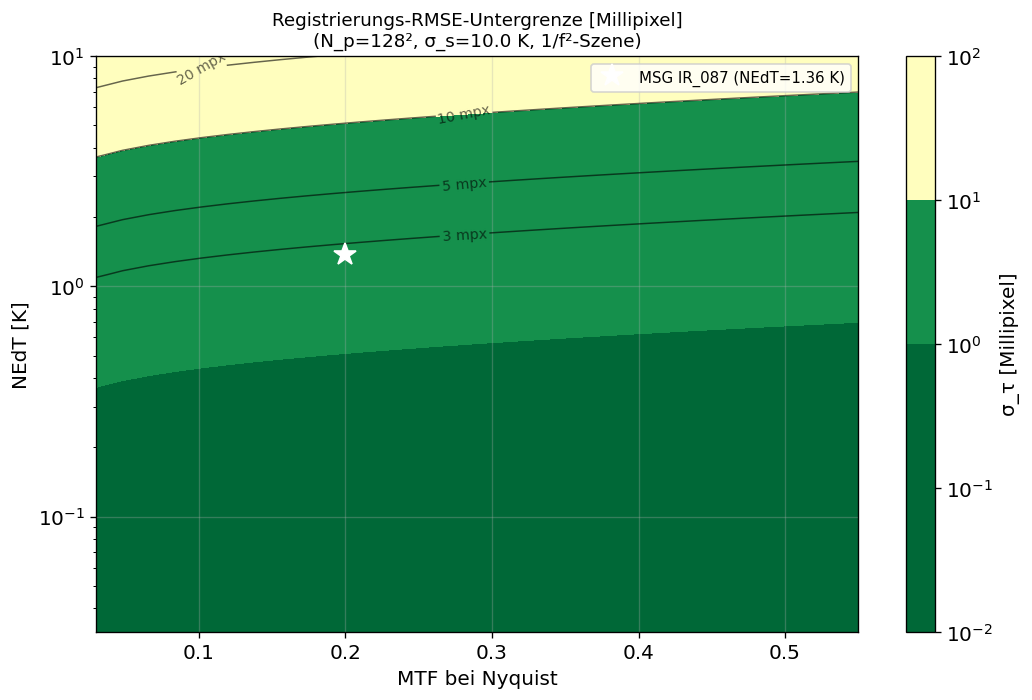

In [8]:
q_hm  = np.linspace(0.03, 0.55, 30)
nd_hm = np.logspace(-1.5, 1.0, 30)
heat  = np.zeros((len(nd_hm), len(q_hm)))

for i, nd in enumerate(nd_hm):
    N_i = psd_noise_2d(nd)
    for j, q in enumerate(q_hm):
        rx, _ = compute_rsnr_2d(mtf_2d(q, q), psd_signal_2d(sigma_s_st), N_i)
        heat[i, j] = sigma_tau_px(rx, Np_study) * 1000

fig, ax = plt.subplots(figsize=(9, 6))
cs = ax.contourf(q_hm, nd_hm, heat, levels=60, cmap='RdYlGn_r',
                 norm=mcolors.LogNorm(vmin=2, vmax=500))
ct = ax.contour(q_hm, nd_hm, heat, levels=[3, 5, 10, 20, 50, 100, 200, 500],
                colors='k', linewidths=0.9, alpha=0.6)
ax.clabel(ct, fmt=lambda v: f'{v:.0f} mpx', fontsize=8.5)
plt.colorbar(cs, ax=ax, label='σ_τ [Millipixel]')
ax.plot(0.20, sig_n_msg, 'w*', ms=14, zorder=5, label=f'MSG IR_087 (NEdT={sig_n_msg:.2f} K)')
ax.set_xlabel('MTF bei Nyquist'); ax.set_ylabel('NEdT [K]'); ax.set_yscale('log')
ax.set_title(f'Registrierungs-RMSE-Untergrenze [Millipixel]\n'
             f'(N_p=128², σ_s={sigma_s_st} K, 1/f²-Szene)', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('cam_plot6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

## RSNR-Budget: 2D-Integrand-Analyse

Der Integrand $f_x^2 \cdot \text{MTF}^2(f_x,f_y) \cdot S/N$ im $(f_x,f_y)$-Raum zeigt direkt, welche Frequenzpaare zur $x$-Registriergenauigkeit beitragen.

Scharf  (q=0.45, NEdT=0.10 K): σ_τ=0 mpx | 50%: f_x=0.215 | 90%: f_x=0.391 cpx
Typisch (q=0.20, NEdT=0.15 K): σ_τ=0 mpx | 50%: f_x=0.174 | 90%: f_x=0.330 cpx
Weich   (q=0.08, NEdT=0.25 K): σ_τ=1 mpx | 50%: f_x=0.146 | 90%: f_x=0.279 cpx


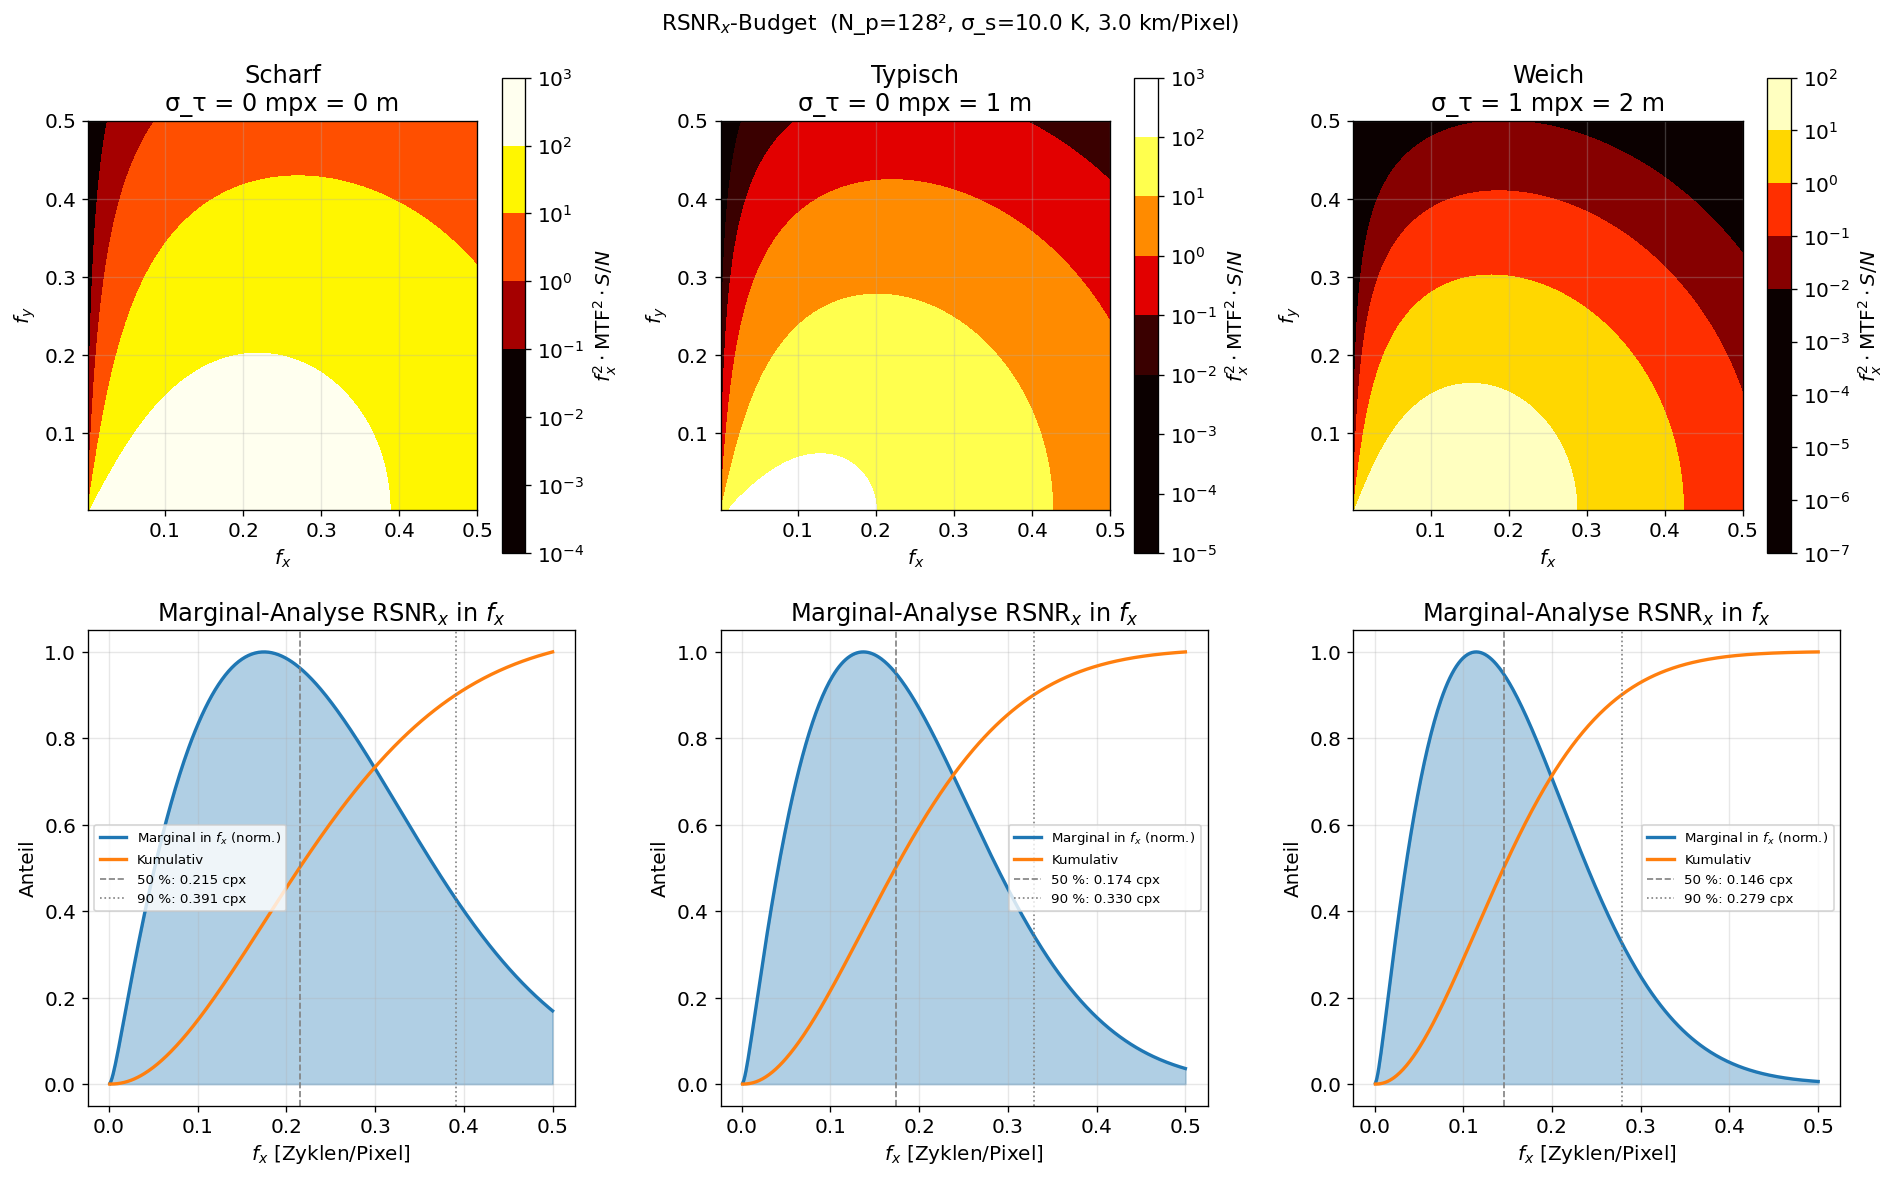

In [9]:
pix_km = 3.0
Np_ex  = 128**2
S_ex   = psd_signal_2d(sigma_s_st)

scenarios = {
    'Scharf  (q=0.45, NEdT=0.10 K)': dict(q=0.45, nedt=0.10),
    'Typisch (q=0.20, NEdT=0.15 K)': dict(q=0.20, nedt=0.15),
    'Weich   (q=0.08, NEdT=0.25 K)': dict(q=0.08, nedt=0.25),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ci, (name, p) in enumerate(scenarios.items()):
    M_i   = mtf_2d(p['q'], p['q'])
    N_i   = psd_noise_2d(p['nedt'])
    ig    = FX**2 * M_i**2 * S_ex / N_i
    rx, _ = compute_rsnr_2d(M_i, S_ex, N_i)
    sig_i = sigma_tau_px(rx, Np_ex) * 1000

    # Zeile 1: 2D-Integrand
    ax = axes[0, ci]
    vmin_i = ig.max() * 1e-4
    cs = ax.contourf(fx, fy, ig, levels=60, cmap='hot',
                     norm=mcolors.LogNorm(vmin=vmin_i, vmax=ig.max()))
    plt.colorbar(cs, ax=ax, label='$f_x^2 \\cdot \\mathrm{MTF}^2 \\cdot S/N$')
    ax.set_xlabel('$f_x$'); ax.set_ylabel('$f_y$')
    ax.set_title(f'{name.split("(")[0].strip()}\nσ_τ = {sig_i:.0f} mpx = {sig_i*pix_km:.0f} m')
    ax.set_aspect('equal')

    # Zeile 2: kumulative Marginalfunktion in f_x
    ax2 = axes[1, ci]
    marg = trapezoid(ig, fy, axis=0)
    cum  = np.cumsum(marg) * (fx[1] - fx[0])
    cum_n = cum / cum[-1]
    f50 = fx[np.searchsorted(cum_n, 0.50)]
    f90 = fx[np.searchsorted(cum_n, 0.90)]
    ax2.fill_between(fx, marg / marg.max(), alpha=0.35, color='C0')
    ax2.plot(fx, marg / marg.max(), 'C0-', lw=2, label='Marginal in $f_x$ (norm.)')
    ax2.plot(fx, cum_n,             'C1-', lw=2, label='Kumulativ')
    ax2.axvline(f50, color='gray', ls='--', lw=1, label=f'50 %: {f50:.3f} cpx')
    ax2.axvline(f90, color='gray', ls=':',  lw=1, label=f'90 %: {f90:.3f} cpx')
    ax2.set_xlabel('$f_x$ [Zyklen/Pixel]'); ax2.set_ylabel('Anteil')
    ax2.set_title('Marginal-Analyse $\\mathrm{RSNR}_x$ in $f_x$')
    ax2.legend(fontsize=8)

    print(f"{name}: σ_τ={sig_i:.0f} mpx | 50%: f_x={f50:.3f} | 90%: f_x={f90:.3f} cpx")

fig.suptitle(f'$\\mathrm{{RSNR}}_x$-Budget  (N_p=128², σ_s={sigma_s_st} K, {pix_km} km/Pixel)', fontsize=13)
plt.tight_layout()
plt.savefig('cam_plot7_budget.png', dpi=150, bbox_inches='tight')
plt.show()